# Feature Engineering

## Анализ сайта "СберАвтоподписка"

Цель ноутбука -> создать дополнительные признаки для модели машинного обучения.

На предыдущем этапе была сформирована целевая переменная `target` на уровне визита.

На этом этапе будут созданы признаки на основе:

- данных о визите пользователя
- UTM-меток
- устройства и браузера
- географии
- времени визита
- агрегированных событий пользователя из `ga_hits`

Итоговый результат ноутбука -> подготовленный датасет `data/processed/sber_auto_dataset.csv`, который будет использоваться для обучения модели.

## Импорты

In [1]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import numpy as np
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## Импорт модулей проекта

In [2]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent
REPOSITORY_DIR = PROJECT_DIR.parents[3]

if str(REPOSITORY_DIR) not in sys.path:
    sys.path.append(str(REPOSITORY_DIR))

from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config import (
    PROCESSED_DATA_DIR,
    PROCESSED_DATASET_PATH,
    TARGET_ACTIONS,
    TARGET_COLUMN,
)

from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.data_loader import load_hits

## Загрузка данных

In [3]:
sessions_with_target_path = PROCESSED_DATA_DIR / "sessions_with_target.csv"

sessions = pd.read_csv(sessions_with_target_path)
hits = load_hits()

print(f"Размер sessions_with_target: {sessions.shape}")
print(f"Размер hits: {hits.shape}")

Размер sessions_with_target: (1860042, 20)
Размер hits: (15726470, 11)


## Первичный просмотр

In [4]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target,traffic_type
0,9055434745589932991.1637753792.1637753792,2108382700.163775,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0,paid
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0,paid
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0,paid
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0,paid
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0,paid


In [5]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 20 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
 18  target                    int64 
 19  traffic_type              object
dtypes: int64(2), object(18)
memory usage: 283.8+ M

In [6]:
sessions[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2)

target
0    96.62
1     3.38
Name: proportion, dtype: float64

## Признаки из таблицы sessions

In [7]:
# Копируем датасет
features_df = sessions.copy()

features_df.shape

(1860042, 20)

In [8]:
# Признаки времени визита
# В sessions есть visit_date и visit_time,
# создадим нормальный datetime и признаки
features_df["visit_datetime"] = pd.to_datetime(
    features_df["visit_date"].astype(str) + " " + features_df["visit_time"].astype(str),
    errors="coerce",
)

features_df["visit_month"] = features_df["visit_datetime"].dt.month
features_df["visit_day"] = features_df["visit_datetime"].dt.day
features_df["visit_weekday"] = features_df["visit_datetime"].dt.weekday
features_df["visit_hour"] = features_df["visit_datetime"].dt.hour
features_df["is_weekend"] = features_df["visit_weekday"].isin([5, 6]).astype(int)

features_df[
    [
        "visit_date",
        "visit_time",
        "visit_datetime",
        "visit_month",
        "visit_day",
        "visit_weekday",
        "visit_hour",
        "is_weekend",
    ]
].head()

,visit_date,visit_time,visit_datetime,visit_month,visit_day,visit_weekday,visit_hour,is_weekend
0,2021-11-24,14:36:32,2021-11-24 14:36:32,11,24,2,14,0
1,2021-11-14,08:21:30,2021-11-14 08:21:30,11,14,6,8,1
2,2021-12-28,02:42:06,2021-12-28 02:42:06,12,28,1,2,0
3,2021-05-29,05:00:00,2021-05-29 05:00:00,5,29,5,5,1
4,2021-05-29,05:00:00,2021-05-29 05:00:00,5,29,5,5,1


## На основе даты и времени визита были созданы календарные признаки:

- месяц
- день месяца
- день недели
- час визита
- выходной день

Эти признаки будут полезны, так как поведение пользователей и вероятность конверсии могут отличаться в зависимости от времени посещения сайта.

## Признаки типа трафика

По условию задачи органический трафик:
`utm_medium in ('organic', 'referral', '(none)')`

In [9]:
# Добавляем признаки
ORGANIC_MEDIUMS = ["organic", "referral", "(none)"]

features_df["is_organic_traffic"] = (
    features_df["utm_medium"]
    .isin(ORGANIC_MEDIUMS)
    .astype(int)
)

features_df["is_paid_traffic"] = 1 - features_df["is_organic_traffic"]

features_df[["utm_medium", "is_organic_traffic", "is_paid_traffic"]].head()

,utm_medium,is_organic_traffic,is_paid_traffic
0,banner,0,1
1,cpm,0,1
2,banner,0,1
3,cpc,0,1
4,cpc,0,1


## Признак социальных сетей

В условии сказано, что соцсети определяются по набору utm_source, но перечень зашифрованных ID в материалах может быть отдельным.
Пока сделаем через utm_medium, потому что явно имеется smm.

In [10]:
features_df["is_social_traffic"] = (
    features_df["utm_medium"]
    .astype(str)
    .str.lower()
    .isin(["smm", "social", "social-network", "social-media"])
    .astype(int)
)

features_df[["utm_medium", "is_social_traffic"]].value_counts().head(20)

utm_medium       is_social_traffic
banner           0                    552272
cpc              0                    434794
(none)           0                    300575
cpm              0                    242083
referral         0                    152050
organic          0                     63034
email            0                     29240
push             0                     28035
stories          0                     10582
cpv              0                      8022
blogger_channel  0                      8015
smartbanner      0                      6794
blogger_stories  0                      4312
cpa              0                      4279
tg               0                      4011
app              0                      2836
post             0                      2326
smm              1                      1985
outlook          0                      1332
clicks           0                       934
Name: count, dtype: int64

Для выделения социального трафика был создан бинарный признак `is_social_traffic`.
В учебном варианте он определяется через `utm_medium`, так как в данных явно присутствует значение `smm`.
Если бы был предоставлен точный список зашифрованных `utm_source`, признак можно было бы уточнить через источник трафика.

## Признак первого визита

In [11]:
features_df["is_first_visit"] = (
    features_df["visit_number"]
    .eq(1)
    .astype(int)
)

features_df[["visit_number", "is_first_visit"]].head()

,visit_number,is_first_visit
0,1,1
1,1,1
2,1,1
3,1,1
4,2,0


## Обработка выбросов в visit_number

visit_number имеет максимум больше 500, поэтому делаем ограниченную версию признака

In [12]:
features_df["visit_number_clipped"] = features_df["visit_number"].clip(upper=20)

features_df[["visit_number", "visit_number_clipped"]].describe()

,visit_number,visit_number_clipped
count,1.860042e+06,1.860042e+06
mean,2.712804e+00,1.960979e+00
std,1.182907e+01,2.957480e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,2.000000e+00,2.000000e+00
max,5.640000e+02,2.000000e+01


Признак `visit_number` отражает порядковый номер визита пользователя.
В данных есть пользователи с очень большим количеством визитов,
поэтому дополнительно создан признак `visit_number_clipped`, в котором значения ограничены сверху.
Это снижает влияние редких экстремальных значений на модель.

## Агрегация событий из hits

Отбираем нужные колонки из hits

In [13]:
# Чтобы экономить память, работаем только с нужными колонками
hits_features = hits[
    [
        "session_id",
        "hit_number",
        "hit_page_path",
        "event_category",
        "event_action",
    ]
].copy()

hits_features.shape

(15726470, 5)

Базовые агрегаты по событиям

In [14]:
# Создадим поведенческие признаки
hits_agg = (
    hits_features
    .groupby("session_id")
    .agg(
        hit_count=("hit_number", "count"),
        max_hit_number=("hit_number", "max"),
        unique_page_count=("hit_page_path", "nunique"),
        unique_event_action_count=("event_action", "nunique"),
        unique_event_category_count=("event_category", "nunique"),
    )
    .reset_index()
)

hits_agg.head()

,session_id,hit_count,max_hit_number,unique_page_count,unique_event_action_count,unique_event_category_count
0,1000009318903347362.1632663668.1632663668,10,15,3,6,4
1,1000010177899156286.1635013443.1635013443,6,12,2,5,4
2,1000013386240115915.1635402956.1635402956,11,17,3,6,5
3,1000017303238376207.1623489300.1623489300,12,18,3,8,6
4,1000020580299877109.1624943350.1624943350,1,3,1,1,1


На основе таблицы `ga_hits` были созданы агрегированные признаки уровня сессии:
- количество событий
- максимальный номер события
- количество уникальных страниц
- количество уникальных действий
- количество уникальных категорий событий

Эти признаки описывают глубину и разнообразие взаимодействия пользователя с сайтом.

Важные группы действий без утечки target

In [15]:
# Группы только для поведенческих действий,
# которые предшествуют конверсии или описывают интерес
BEHAVIOR_ACTION_GROUPS = {
    "has_view_card": [
        "view_card",
        "view_new_card",
        "view_used_card",
        "go_to_car_card",
        "greenday_go_to_car_card",
        "greenday_view_new_card",
    ],
    "has_search": [
        "search_form_search_btn",
        "search_form_region",
        "search_form_cost_from",
        "search_form_cost_to",
        "search_form_mark_select",
        "search_form_model_select",
        "search_form_rental",
        "search_body_type",
        "search_color",
        "search_drive",
        "search_engine",
        "search_km_from",
        "search_km_to",
        "search_kpp",
        "search_power_from",
        "search_power_to",
        "search_steering_wheel",
    ],
    "has_pagination": [
        "pagination_click",
    ],
    "has_quiz": [
        "quiz_show",
        "quiz_start",
    ],
    "has_subscription_interest": [
        "auto_subscription_click",
        "click_auto_subscription",
        "click_on_subscription",
        "sub_banner_click",
        "sub_car_page",
        "sub_landing",
        "sub_offer_click",
        "sub_view_cars_click",
        "greenday_sub_landing",
        "greenday_sub_view_cars_click",
    ],
    "has_phone_interaction": [
        "show_phone_input",
        "phone_entered",
        "phone_entered_on_form_request_call",
        "tap_on_phone_495",
        "tap_on_phone_800",
    ],
    "has_form_interaction": [
        "show_form_lets_get_acquainted",
        "showed_form_request_call",
        "name_entered",
        "name_entered_on_form_request_call",
        "surname_entered",
        "patronymic_entered",
    ],
}

In [16]:
# Проверяем, что случайно не добавили целевые действия,
# должен быть пустой вывод
target_actions_set = set(TARGET_ACTIONS)

for group_name, actions in BEHAVIOR_ACTION_GROUPS.items():
    intersection = target_actions_set.intersection(actions)

    if intersection:
        print(f"В группе {group_name} есть пересечение с TARGET_ACTIONS: {intersection}")

Создаем бинарные признаки по группам событий

In [17]:
behavior_features = pd.DataFrame({
    "session_id": hits_features["session_id"].drop_duplicates()
})

for feature_name, actions in BEHAVIOR_ACTION_GROUPS.items():
    sessions_with_action = (
        hits_features
        .loc[hits_features["event_action"].isin(actions), "session_id"]
        .drop_duplicates()
    )

    behavior_features[feature_name] = (
        behavior_features["session_id"]
        .isin(sessions_with_action)
        .astype(int)
    )

behavior_features.head()

,session_id,has_view_card,has_search,has_pagination,has_quiz,has_subscription_interest,has_phone_interaction,has_form_interaction
0,5639623078712724064.1640254056.1640254056,1,1,0,1,0,0,0
1,7750352294969115059.1640271109.1640271109,0,1,0,1,1,1,1
2,885342191847998240.1640235807.1640235807,1,0,0,1,1,0,0
3,142526202120934167.1640211014.1640211014,1,0,1,1,1,0,0
4,3450086108837475701.1640265078.1640265078,1,1,1,1,1,0,0


In [18]:
# Проверяем доли
behavior_features.drop(columns="session_id").mean().sort_values(ascending=False).mul(100).round(2)

has_subscription_interest    82.49
has_view_card                39.92
has_search                   18.10
has_quiz                      9.91
has_pagination                6.60
has_phone_interaction         1.56
has_form_interaction          0.39
dtype: float64

Объединяем агрегаты из hits

In [19]:
hits_session_features = (
    hits_agg
    .merge(
        behavior_features,
        on="session_id",
        how="left",
    )
)

hits_session_features.head()

,session_id,hit_count,max_hit_number,unique_page_count,unique_event_action_count,unique_event_category_count,has_view_card,has_search,has_pagination,has_quiz,has_subscription_interest,has_phone_interaction,has_form_interaction
0,1000009318903347362.1632663668.1632663668,10,15,3,6,4,1,0,0,0,1,0,0
1,1000010177899156286.1635013443.1635013443,6,12,2,5,4,0,1,0,0,1,0,0
2,1000013386240115915.1635402956.1635402956,11,17,3,6,5,1,0,0,0,1,0,0
3,1000017303238376207.1623489300.1623489300,12,18,3,8,6,1,1,0,1,1,0,0
4,1000020580299877109.1624943350.1624943350,1,3,1,1,1,0,0,0,1,0,0,0


Объединяем sessions и hits-признаки

In [20]:
model_dataset = (
    features_df
    .merge(
        hits_session_features,
        on="session_id",
        how="left",
    )
)

model_dataset.shape

(1860042, 43)

Так как не все сессии из ga_sessions могут быть в ga_hits,
пропуски в агрегатах заполняем нулями

In [21]:
hit_feature_columns = [
    "hit_count",
    "max_hit_number",
    "unique_page_count",
    "unique_event_action_count",
    "unique_event_category_count",
    *BEHAVIOR_ACTION_GROUPS.keys(),
]

model_dataset[hit_feature_columns] = model_dataset[hit_feature_columns].fillna(0)

model_dataset[hit_feature_columns].isna().sum()

hit_count                      0
max_hit_number                 0
unique_page_count              0
unique_event_action_count      0
unique_event_category_count    0
has_view_card                  0
has_search                     0
has_pagination                 0
has_quiz                       0
has_subscription_interest      0
has_phone_interaction          0
has_form_interaction           0
dtype: int64

## Анализ новых признаков

CR по бинарным признакам поведения

In [22]:
def calculate_binary_feature_cr(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str = "target",
) -> pd.DataFrame:
    """
    Рассчитывает конверсию для бинарных признаков.

    Аргументы:
        - data: DataFrame с признаками и целевой переменной
        - feature_columns: Список бинарных признаков
        - target_column: Название целевой переменной

    Возвращает:
        - DataFrame со статистикой по каждому бинарному признаку
    """

    rows = []

    for column in feature_columns:
        active_mask = data[column].eq(1)
        active_visits = active_mask.sum()
        active_target_visits = data.loc[active_mask, target_column].sum()
        active_cr = data.loc[active_mask, target_column].mean()

        rows.append(
            {
                "feature": column,
                "active_visits": active_visits,
                "active_target_visits": active_target_visits,
                "active_cr_percent": round(active_cr * 100, 2),
            }
        )

    result = (
        pd.DataFrame(rows)
        .sort_values("active_cr_percent", ascending=False)
        .reset_index(drop=True)
    )

    return result

In [23]:
# Запускаем
binary_feature_cr = calculate_binary_feature_cr(
    data=model_dataset,
    feature_columns=list(BEHAVIOR_ACTION_GROUPS.keys()),
    target_column=TARGET_COLUMN,
)

binary_feature_cr

,feature,active_visits,active_target_visits,active_cr_percent
0,has_form_interaction,6707,4584,68.35
1,has_phone_interaction,26806,12326,45.98
2,has_quiz,171700,13263,7.72
3,has_search,313709,21679,6.91
4,has_view_card,691029,42481,6.15
5,has_pagination,114404,6674,5.83
6,has_subscription_interest,1429910,52617,3.68


## Выводы по поведенческим признакам

Анализ бинарных поведенческих признаков показал, что действия пользователя внутри сессии заметно связаны с вероятностью конверсии.

Самую высокую конверсию показывают признаки `has_form_interaction` и `has_phone_interaction`.
Однако эти признаки отражают позднюю стадию пользовательского пути, ввод имени, телефона или взаимодействие с формой.
Такие действия происходят очень близко к целевому событию и могут привести к утечке целевой переменной.

Поэтому эти признаки были использованы для аналитики, но исключены из финального датасета для обучения модели.

Для модели оставлены более ранние поведенческие признаки:

- просмотр карточек автомобилей
- использование поиска
- пагинация
- взаимодействие с квизом
- интерес к разделу подписки

Эти признаки описывают вовлеченность пользователя, но не являются прямым аналогом целевого действия.

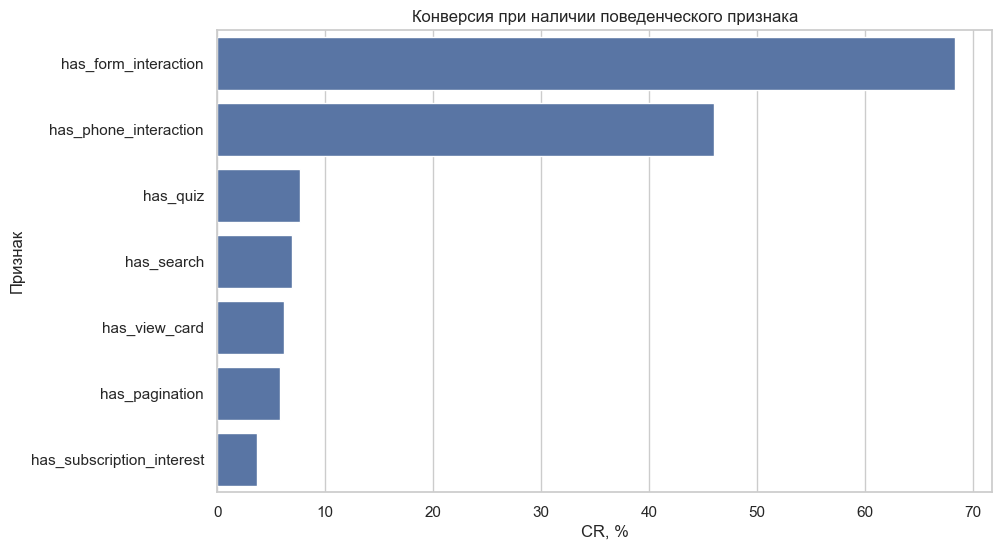

In [24]:
# График для наглядности
plt.figure(figsize=(10, 6))
sns.barplot(
    data=binary_feature_cr,
    x="active_cr_percent",
    y="feature",
)
plt.title("Конверсия при наличии поведенческого признака")
plt.xlabel("CR, %")
plt.ylabel("Признак")
plt.show()

Поведенческие признаки из таблицы `ga_hits` описывают глубину интереса пользователя.
Если пользователь просматривал карточки автомобилей, использовал поиск, взаимодействовал с формой,
квизом или блоками подписки, вероятность целевого действия может отличаться от средней по выборке.

Корреляция числовых признаков

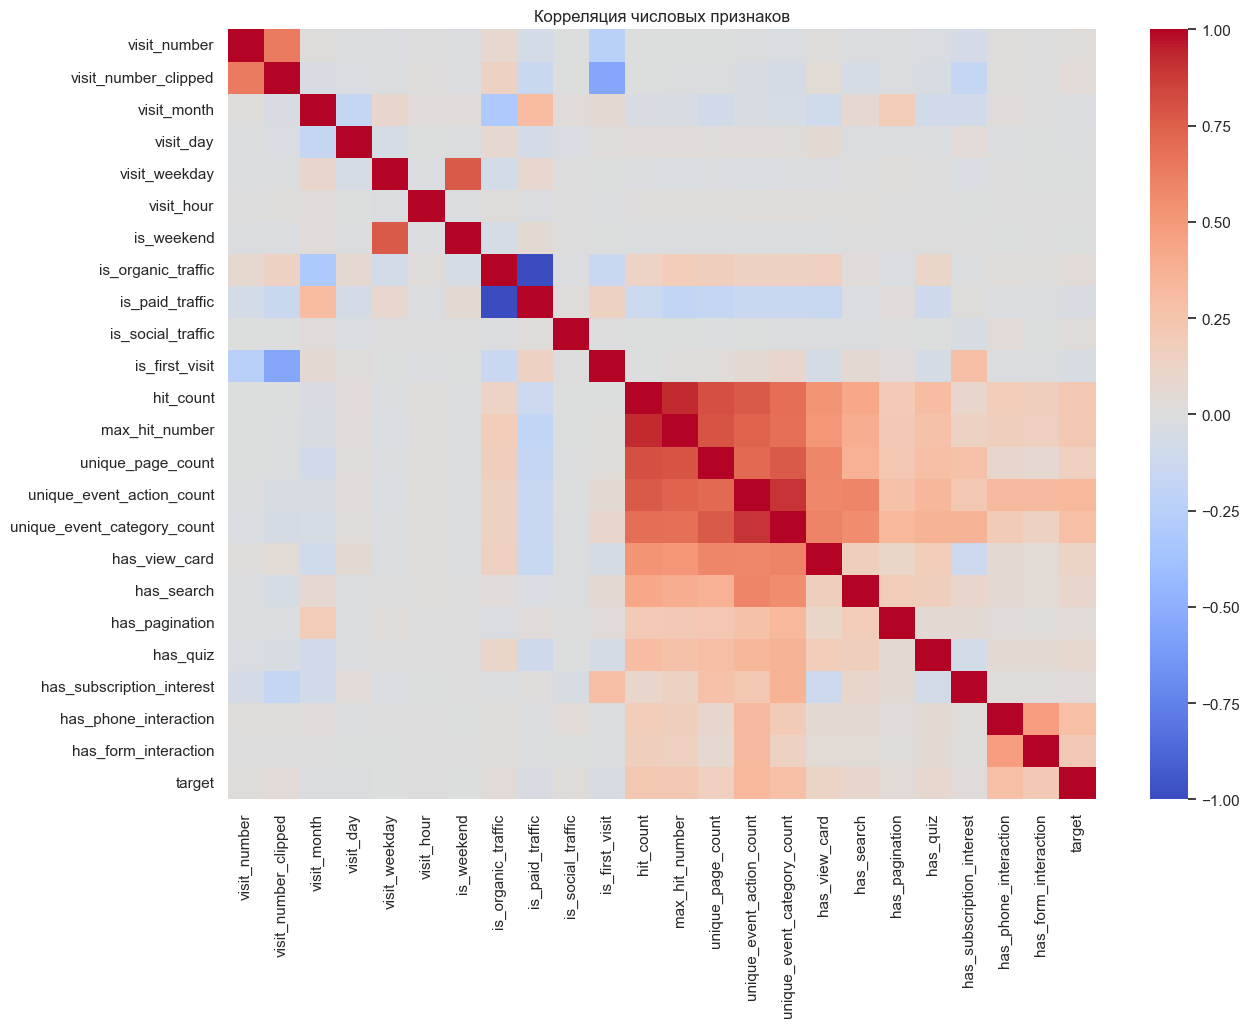

In [25]:
numeric_columns = [
    "visit_number",
    "visit_number_clipped",
    "visit_month",
    "visit_day",
    "visit_weekday",
    "visit_hour",
    "is_weekend",
    "is_organic_traffic",
    "is_paid_traffic",
    "is_social_traffic",
    "is_first_visit",
    "hit_count",
    "max_hit_number",
    "unique_page_count",
    "unique_event_action_count",
    "unique_event_category_count",
    *BEHAVIOR_ACTION_GROUPS.keys(),
    TARGET_COLUMN,
]

corr_matrix = model_dataset[numeric_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
)
plt.title("Корреляция числовых признаков")
plt.show()

Корреляционная матрица показывает линейные связи между числовыми признаками и целевой переменной.
Для бинарной целевой переменной сильных линейных связей может не быть.
В данном случае корреляция помогает выявить признаки, которые потенциально связаны с конверсией,
в том числе признаки, сильно дублирующие друг друга.

## Финальная очистка перед моделированием

На моделирование не тащим технические и слишком проблемные поля

In [26]:
columns_to_drop = [
    # Идентификаторы
    "session_id",
    "client_id",

    # Исходные дата/время, так как признаки уже извлечены
    "visit_date",
    "visit_time",
    "visit_datetime",

    # Почти полностью пустой признак
    "device_model",

    # Вспомогательный признак, дублирует бинарные is_organic/is_paid
    "traffic_type",

    # Потенциальная утечка целевой переменной,
    # признаки отражают позднюю стадию заполнения формы или ввода телефона
    "has_form_interaction",
    "has_phone_interaction",
]

existing_columns_to_drop = [
    column for column in columns_to_drop
    if column in model_dataset.columns
]

final_dataset = model_dataset.drop(columns=existing_columns_to_drop)

final_dataset.shape

(1860042, 34)

Проверяем итоговый датасет

In [27]:
final_dataset.head()

,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target,visit_month,visit_day,visit_weekday,visit_hour,is_weekend,is_organic_traffic,is_paid_traffic,is_social_traffic,is_first_visit,visit_number_clipped,hit_count,max_hit_number,unique_page_count,unique_event_action_count,unique_event_category_count,has_view_card,has_search,has_pagination,has_quiz,has_subscription_interest
0,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0,11,24,2,14,0,0,1,0,1,1,2.0,4.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
1,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0,11,14,6,8,1,0,1,0,1,1,1.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0,12,28,1,2,0,0,1,0,1,1,16.0,20.0,2.0,3.0,3.0,0.0,1.0,0.0,0.0,1.0
3,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,1,1,3.0,7.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,0,2,2.0,3.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0


In [28]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 34 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   visit_number                 int64  
 1   utm_source                   object 
 2   utm_medium                   object 
 3   utm_campaign                 object 
 4   utm_adcontent                object 
 5   utm_keyword                  object 
 6   device_category              object 
 7   device_os                    object 
 8   device_brand                 object 
 9   device_screen_resolution     object 
 10  device_browser               object 
 11  geo_country                  object 
 12  geo_city                     object 
 13  target                       int64  
 14  visit_month                  int32  
 15  visit_day                    int32  
 16  visit_weekday                int32  
 17  visit_hour                   int32  
 18  is_weekend                   int64  
 19  

In [29]:
final_dataset[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2)

target
0    96.62
1     3.38
Name: proportion, dtype: float64

Пропуски

In [30]:
final_missing = (
    final_dataset
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

final_missing.columns = ["column", "missing_percent"]
final_missing.head(30)

,column,missing_percent
0,utm_keyword,58.17
1,device_os,57.53
2,device_brand,19.74
3,utm_adcontent,18.04
4,utm_campaign,11.81
5,utm_source,0.01
6,visit_number,0.00
7,unique_page_count,0.00
8,is_first_visit,0.00
9,visit_number_clipped,0.00


На этом этапе пропуски в категориальных признаках не заполняем руками,
так как в 03_modeling.ipynb планируем Pipeline с SimpleImputer.

## Проверка признаков на риск утечки данных

На предыдущем шаге были созданы агрегированные признаки на основе таблицы `ga_hits`.
Они описывают поведение пользователя внутри сессии:

- количество событий
- количество уникальных страниц
- количество уникальных действий
- наличие взаимодействий с поиском, карточками, формами, квизом и тд

Однако целевая переменная `target` также формируется на основе `ga_hits.event_action`.

Это создает риск утечки данных -> если признаки рассчитываются по всей сессии, то они могут включать события, произошедшие после целевого действия.

В реальном сценарии предсказания на момент начала визита такие данные недоступны.
Поэтому в финальный датасет для обучения модели эти признаки не включаются.

`ga_hits` используется только для формирования целевой переменной.
Финальная модель обучается на признаках из `ga_sessions` и производных признаках, доступных на момент начала визита.

In [31]:
leakage_risk_features = [
    "hit_count",
    "max_hit_number",
    "unique_page_count",
    "unique_event_action_count",
    "unique_event_category_count",
    "has_view_card",
    "has_search",
    "has_pagination",
    "has_quiz",
    "has_subscription_interest",
    "has_phone_interaction",
    "has_form_interaction",
]

existing_leakage_risk_features = [
    column for column in leakage_risk_features
    if column in final_dataset.columns
]

print("Признаки с риском утечки данных:")
existing_leakage_risk_features

Признаки с риском утечки данных:


['hit_count',
 'max_hit_number',
 'unique_page_count',
 'unique_event_action_count',
 'unique_event_category_count',
 'has_view_card',
 'has_search',
 'has_pagination',
 'has_quiz',
 'has_subscription_interest']

In [32]:
dataset_without_leakage = final_dataset.drop(columns=existing_leakage_risk_features)

print(f"Размер датасета до удаления признаков с риском утечки: {final_dataset.shape}")
print(f"Размер датасета после удаления признаков с риском утечки: {dataset_without_leakage.shape}")

Размер датасета до удаления признаков с риском утечки: (1860042, 34)
Размер датасета после удаления признаков с риском утечки: (1860042, 24)


## Сохраняем итоговый датасет для моделей

In [33]:
dataset_without_leakage.to_csv(PROCESSED_DATASET_PATH, index=False)

print(f"Итоговый датасет сохранен: {PROCESSED_DATASET_PATH}")
print(f"Размер итогового датасета: {dataset_without_leakage.shape}")

Итоговый датасет сохранен: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/data/processed/sber_auto_dataset.csv
Размер итогового датасета: (1860042, 24)
